# Task 2.3 — Medial Axis Detection of Moving Surgical Tools

**Pipeline:**
1. Background Subtraction (median-based static background model)
2. Image Cleaning (morphological erosion + dilation)
3. Edge & Line Detection (Sobel derivatives + custom line detection)
4. Medial Axis Localization (midpoint of opposite edge lines → overlay on frame)

**Constraint:** NO built-in `cv2.HoughLines` / `cv2.HoughLinesP` — Hough coded from scratch.

In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

## Paths

In [ ]:
VIDEO_DIR  = 'input'
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1. Background Subtraction

Build a static background model by computing the **per-pixel median** across every frame.

In [3]:
def get_background_image(video_path):
    """Compute per-pixel median across all frames → static background."""
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()
    background = np.median(np.array(frames), axis=0).astype(np.uint8)
    return background


def subtract_background(frame, background, threshold=30):
    """Binary foreground mask: pixels differing from background by > threshold → 255."""
    diff      = cv2.absdiff(frame, background)
    gray_diff = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, fg_mask = cv2.threshold(gray_diff, threshold, 255, cv2.THRESH_BINARY)
    return fg_mask

## 2. Image Cleaning (Morphological Operations)

- **Opening** (erode → dilate): removes small noise blobs (Not doing this)
- **Closing** (dilate → erode): fills small holes inside the tool

In [4]:
def clean_mask(fg_mask):
    """Morphological open + close to clean the foreground silhouette."""
    kernel_large = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))

    cleaned = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel_large, iterations=3)
    return cleaned

## 3a. Edge Detection (Sobel Derivatives)

First-order Sobel gradients in X and Y → gradient magnitude → binary threshold.

In [5]:
def detect_edges(mask):
    """Sobel gradient magnitude → binary edge map."""
    blurred = cv2.GaussianBlur(mask, (5, 5), 1.0)

    grad_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    mag_max   = magnitude.max()
    if mag_max == 0:
        return np.zeros_like(mask)

    magnitude = np.uint8(magnitude / mag_max * 255)
    _, edges  = cv2.threshold(magnitude, 50, 255, cv2.THRESH_BINARY)
    return edges

## 3b. Custom Line Detection



In [6]:

# ── Custom Hough Transform (from scratch) ──────────────────────────────────

def hough_transform(edge_map, theta_res=1, rho_res=1):
    """Manual Hough line transform — fully vectorised.

    For every white pixel (y, x) in the edge map, vote in the
    (rho, theta) accumulator:  rho = x·cos(theta) + y·sin(theta)

    Args:
        edge_map : uint8 binary image (255 = edge)
        theta_res: angular resolution in degrees
        rho_res  : rho resolution in pixels

    Returns:
        accumulator : 2-D vote array  [rho_idx, theta_idx]
        rhos        : 1-D array of rho bin centres
        thetas      : 1-D array of theta bin centres (radians)
    """
    h, w = edge_map.shape[:2]
    diag = int(np.ceil(np.hypot(h, w)))

    # Theta bins: 0 to 180° (exclusive)
    thetas = np.deg2rad(np.arange(0, 180, theta_res))
    # Rho bins: -diag to +diag
    rhos   = np.arange(-diag, diag + 1, rho_res)

    n_thetas = len(thetas)
    n_rhos   = len(rhos)

    # Pre-compute cos/sin tables
    cos_t = np.cos(thetas)   # (n_thetas,)
    sin_t = np.sin(thetas)   # (n_thetas,)

    # Get edge pixel coordinates
    ys, xs = np.where(edge_map > 0)

    if len(xs) == 0:
        return np.zeros((n_rhos, n_thetas), dtype=np.int32), rhos, thetas

    # Vectorised vote: (n_pixels, n_thetas)
    rho_vals = xs[:, None] * cos_t + ys[:, None] * sin_t

    # Convert to integer bin indices
    rho_idxs = np.round((rho_vals - rhos[0]) / rho_res).astype(np.int32)

    # Theta indices broadcast to same shape
    theta_idxs = np.broadcast_to(
        np.arange(n_thetas, dtype=np.int32), rho_idxs.shape
    )

    # Mask out-of-bounds votes
    valid      = (rho_idxs >= 0) & (rho_idxs < n_rhos)
    flat_idx   = rho_idxs[valid] * n_thetas + theta_idxs[valid]

    acc = np.bincount(flat_idx, minlength=n_rhos * n_thetas)
    acc = acc.reshape(n_rhos, n_thetas).astype(np.int32)

    return acc, rhos, thetas


def find_lines(acc, rhos, thetas, threshold=None, n_lines=6,
               nms_rho=10, nms_theta_deg=10):
    """Extract the top lines from the Hough accumulator with
    non-maximum suppression.

    Args:
        acc          : accumulator from hough_transform
        rhos, thetas : bin centres
        threshold    : minimum votes (default: 20 % of max)
        n_lines      : maximum number of lines to return
        nms_rho      : suppression radius in rho pixels
        nms_theta_deg: suppression radius in degrees

    Returns:
        list of (rho, theta) tuples sorted by vote count (descending)
    """
    if threshold is None:
        threshold = int(0.20 * acc.max())

    nms_theta = int(nms_theta_deg)   # in bin indices (1° each)
    nms_r     = int(nms_rho)

    # Work on a copy so we can zero-out suppressed regions
    acc_copy = acc.copy()
    lines = []

    for _ in range(n_lines):
        idx = np.unravel_index(np.argmax(acc_copy), acc_copy.shape)
        peak_val = acc_copy[idx]
        if peak_val < threshold:
            break

        ri, ti = idx
        lines.append((rhos[ri], thetas[ti]))

        # Suppress neighbourhood
        r_lo = max(0, ri - nms_r)
        r_hi = min(acc_copy.shape[0], ri + nms_r + 1)
        t_lo = max(0, ti - nms_theta)
        t_hi = min(acc_copy.shape[1], ti + nms_theta + 1)
        acc_copy[r_lo:r_hi, t_lo:t_hi] = 0

    return lines


def detect_lines(edge_map):
    """Run the full custom Hough pipeline on a binary edge map.
    Returns a list of (rho, theta) tuples (top lines)."""
    acc, rhos, thetas = hough_transform(edge_map, theta_res=1, rho_res=1)
    lines = find_lines(acc, rhos, thetas, n_lines=6)
    return lines, acc, rhos, thetas


## 4. Medial Axis Localization

Classify detected lines into two parallel edges of the tool, then compute the medial axis as the midpoint line between them.

In [7]:

def _normalize_hough(rho, theta):
    """Ensure theta in [0, pi) and rho adjusted accordingly."""
    theta = theta % (2 * np.pi)
    if theta >= np.pi:
        theta -= np.pi
        rho = -rho
    return rho, theta


def _line_x_at_y(rho, theta, y):
    """Where does the Hough line cross a horizontal scanline y?
    Returns x, or None if the line is nearly horizontal (cos θ ≈ 0)."""
    c = np.cos(theta)
    if abs(c) < 1e-6:
        return None
    return (rho - y * np.sin(theta)) / c


def _line_y_at_x(rho, theta, x):
    """Where does the Hough line cross a vertical scanline x?
    Returns y, or None if the line is nearly vertical (sin θ ≈ 0)."""
    s = np.sin(theta)
    if abs(s) < 1e-6:
        return None
    return (rho - x * np.cos(theta)) / s


def _intersection(rho1, theta1, rho2, theta2):
    """Compute the intersection point (x, y) of two Hough lines.
    Returns (x, y) or None if lines are parallel."""
    c1, s1 = np.cos(theta1), np.sin(theta1)
    c2, s2 = np.cos(theta2), np.sin(theta2)
    det = c1 * s2 - s1 * c2
    if abs(det) < 1e-10:
        return None  # parallel
    x = ( s2 * rho1 - s1 * rho2) / det
    y = (-c2 * rho1 + c1 * rho2) / det
    return (x, y)


def _pair_intersects_inside(r1, t1, r2, t2, h, w):
    """Check whether a PAIR of lines intersect inside the image [0, w) x [0, h)."""
    pt = _intersection(r1, t1, r2, t2)
    if pt is None:
        return False  # parallel → never intersect (good for edge pairs)
    x, y = pt
    return 0 <= x < w and 0 <= y < h


def _line_separation(rho1, theta1, rho2, theta2, h, w):
    """Pixel separation between two lines measured at the image centre."""
    avg_theta = (theta1 + theta2) / 2.0

    if abs(np.cos(avg_theta)) >= abs(np.sin(avg_theta)):
        x1 = _line_x_at_y(rho1, theta1, h / 2.0)
        x2 = _line_x_at_y(rho2, theta2, h / 2.0)
        if x1 is not None and x2 is not None:
            return abs(x1 - x2)
    else:
        y1 = _line_y_at_x(rho1, theta1, w / 2.0)
        y2 = _line_y_at_x(rho2, theta2, w / 2.0)
        if y1 is not None and y2 is not None:
            return abs(y1 - y2)

    return abs(rho1 - rho2)


def _angular_diff(t1, t2):
    """Wrapped angular difference in [0, pi/2]."""
    dt = abs(t1 - t2)
    return min(dt, np.pi - dt)


def _best_pair_by_separation(normed, h, w, angle_limit_deg=20):
    """Fallback mechanism: pick the two near-parallel lines with max spatial
    separation.  Returns (line1, line2) or None."""
    best_pair = None
    best_sep  = -1.0

    for i in range(len(normed)):
        for j in range(i + 1, len(normed)):
            r1, t1 = normed[i]
            r2, t2 = normed[j]

            if _angular_diff(t1, t2) > np.deg2rad(angle_limit_deg):
                continue

            sep = _line_separation(r1, t1, r2, t2, h, w)
            if sep > best_sep:
                best_sep  = sep
                best_pair = (normed[i], normed[j])

    return best_pair


# Mode labels returned alongside the pair for debugging
MODE_NORMAL       = "normal"           # pair selected via intersection-filtered + theta-ranked
MODE_FALLBACK_ALL = "fallback_all"     # all pairs eliminated → fallback on full set
MODE_NO_LINES     = "no_lines"         # fewer than 2 lines detected


def classify_edge_pair(lines, img_shape):
    """Pick the best pair of edge lines for medial-axis computation.

    Strategy (filter PAIRS, not individual lines):
    -----------------------------------------------
    1. Generate all pairs of normalised lines.
    2. Discard pairs that intersect inside the image — true tool edges are
       nearly parallel and should not converge within the frame.
    3. Among surviving pairs, pick by:
       a) smallest angular difference (most parallel), then
       b) largest spatial separation to break ties (within 2° tolerance).
    4. If NO pairs survive step 2, fall back to the original separation-based
       mechanism using all lines.

    Returns:
        (pair, mode) where pair is (line1, line2) or None,
        and mode is one of MODE_NORMAL, MODE_FALLBACK_ALL, MODE_NO_LINES.
    """
    if len(lines) < 2:
        return None, MODE_NO_LINES

    h, w = img_shape[:2]
    normed = [_normalize_hough(r, t) for r, t in lines]
    n = len(normed)

    # ── Step 1–2: Build candidate pairs that do NOT intersect inside the image ──
    good_pairs = []   # (angular_diff, separation, i, j)

    for i in range(n):
        for j in range(i + 1, n):
            r1, t1 = normed[i]
            r2, t2 = normed[j]

            # Skip pairs that intersect inside the image
            if _pair_intersects_inside(r1, t1, r2, t2, h, w):
                continue

            dt  = _angular_diff(t1, t2)
            sep = _line_separation(r1, t1, r2, t2, h, w)
            good_pairs.append((dt, sep, i, j))

    # ── Fallback: no valid pair survived ──
    if len(good_pairs) == 0:
        result = _best_pair_by_separation(normed, h, w)
        if result is not None:
            return result, MODE_FALLBACK_ALL
        return (normed[0], normed[1]), MODE_FALLBACK_ALL

    # ── Step 3a: Sort by angular difference (ascending = most parallel first) ──
    good_pairs.sort(key=lambda x: x[0])

    best_dt = good_pairs[0][0]
    ANGLE_TIE_TOL = np.deg2rad(2)

    # Gather all pairs within 2° of the best angular difference
    tied = [(sep, i, j) for dt, sep, i, j in good_pairs
            if dt - best_dt <= ANGLE_TIE_TOL]

    # ── Step 3b: Among tied pairs, pick the one with largest separation ──
    tied.sort(key=lambda x: x[0], reverse=True)  # descending separation
    _, bi, bj = tied[0]

    return (normed[bi], normed[bj]), MODE_NORMAL


def medial_axis_line(line1, line2):
    """Compute the angular bisector of two (rho, theta) Hough lines."""
    rho1, theta1 = _normalize_hough(*line1)
    rho2, theta2 = _normalize_hough(*line2)

    dtheta = abs(theta1 - theta2)
    dtheta = min(dtheta, np.pi - dtheta)

    if dtheta < np.deg2rad(10):
        if np.cos(theta1 - theta2) < 0:
            rho2, theta2 = -rho2, theta2 + np.pi
        while theta2 - theta1 > np.pi:
            theta2 -= 2 * np.pi
        while theta1 - theta2 > np.pi:
            theta2 += 2 * np.pi
        rho_mid   = (rho1 + rho2) / 2.0
        theta_mid = (theta1 + theta2) / 2.0
        return _normalize_hough(rho_mid, theta_mid)

    c1, s1 = np.cos(theta1), np.sin(theta1)
    c2, s2 = np.cos(theta2), np.sin(theta2)
    det = c1 * s2 - s1 * c2

    if abs(det) < 1e-10:
        rho_mid   = (rho1 + rho2) / 2.0
        theta_mid = (theta1 + theta2) / 2.0
        return _normalize_hough(rho_mid, theta_mid)

    x0 = ( s2 * rho1 - s1 * rho2) / det
    y0 = (-c2 * rho1 + c1 * rho2) / det

    d1 = np.array([-s1, c1])
    d2 = np.array([-s2, c2])
    if np.dot(d1, d2) < 0:
        d2 = -d2

    bis = d1 + d2
    bis_len = np.linalg.norm(bis)
    if bis_len < 1e-10:
        bis = d1
    else:
        bis = bis / bis_len

    nx, ny = bis[1], -bis[0]
    theta_b = np.arctan2(ny, nx)
    rho_b   = x0 * nx + y0 * ny

    return _normalize_hough(rho_b, theta_b)

## Drawing Helpers

In [8]:
def draw_line(image, rho, theta, color, thickness=2):
    """Draw an infinite (rho, theta) line across the image."""
    a, b = np.cos(theta), np.sin(theta)
    x0, y0 = a * rho, b * rho
    L = max(image.shape[:2]) * 2
    pt1 = (int(x0 - L * b), int(y0 + L * a))
    pt2 = (int(x0 + L * b), int(y0 - L * a))
    cv2.line(image, pt1, pt2, color, thickness)


def overlay_result(frame, line1, line2, medial):
    """Draw edge lines (green) and medial axis (red) on the frame."""
    vis = frame.copy()
    draw_line(vis, line1[0], line1[1], color=(0, 255, 0), thickness=1)
    draw_line(vis, line2[0], line2[1], color=(0, 255, 0), thickness=1)
    draw_line(vis, medial[0], medial[1], color=(0, 0, 255), thickness=2)
    return vis

## Staged Pipeline Functions

Each stage saves its output to disk. On re-run, if the output already exists, the stage **skips** and loads the cached result. To force a re-run of a specific stage, delete its output file before running.

In [9]:

from collections import Counter


def stage1_background_subtraction(video_path, idx):
    """Stage 1: Build background model and write foreground mask video.
    Skips if outputs already exist.

    Outputs saved:
        background_{idx}.jpg  — static background image
        foreground_{idx}.mp4  — per-frame binary foreground masks

    Returns:
        background   : np.ndarray
        fg_path      : str
        sample_fg    : np.ndarray (sample from mid-video)
        sample_frame : np.ndarray (original frame at mid-video)
    """
    bg_path = os.path.join(OUTPUT_DIR, f"background_{idx}.jpg")
    fg_path = os.path.join(OUTPUT_DIR, f"foreground_{idx}.mp4")

    if os.path.exists(bg_path) and os.path.exists(fg_path):
        print(f"  [Stage 1] Outputs exist — loading cached results")
        background = cv2.imread(bg_path)
        cap = cv2.VideoCapture(fg_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        mid = max(total // 2, 1)
        cap.set(cv2.CAP_PROP_POS_FRAMES, mid - 1)
        _, sample_fg = cap.read()
        cap.release()
        if sample_fg is not None and sample_fg.ndim == 3:
            sample_fg = cv2.cvtColor(sample_fg, cv2.COLOR_BGR2GRAY)
        # Also grab original frame at midpoint
        cap_orig = cv2.VideoCapture(video_path)
        cap_orig.set(cv2.CAP_PROP_POS_FRAMES, mid - 1)
        _, sample_frame = cap_orig.read()
        cap_orig.release()
        return background, fg_path, sample_fg, sample_frame

    print(f"  [Stage 1] Building background model (median of all frames)...")
    background = get_background_image(video_path)
    cv2.imwrite(bg_path, background)

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    mid = max(total // 2, 1)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(fg_path, fourcc, fps, (w, h), isColor=False)

    sample_fg = None
    sample_frame = None
    frame_num = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_num += 1
        fg_mask = subtract_background(frame, background)
        out.write(fg_mask)
        if frame_num == mid:
            sample_fg = fg_mask.copy()
            sample_frame = frame.copy()

    cap.release()
    out.release()
    print(f"    Saved {frame_num} foreground frames → {fg_path}")
    return background, fg_path, sample_fg, sample_frame


def stage2_clean_masks(fg_path, idx):
    """Stage 2: Morphological cleaning of foreground masks.
    Skips if output already exists.

    Outputs saved:
        cleaned_{idx}.mp4 — morphologically cleaned masks

    Returns:
        clean_path     : str
        sample_cleaned : np.ndarray
    """
    clean_path = os.path.join(OUTPUT_DIR, f"cleaned_{idx}.mp4")

    if os.path.exists(clean_path):
        print(f"  [Stage 2] Output exists — loading cached result")
        cap = cv2.VideoCapture(clean_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        mid = max(total // 2, 1)
        cap.set(cv2.CAP_PROP_POS_FRAMES, mid - 1)
        _, sample_cleaned = cap.read()
        cap.release()
        if sample_cleaned is not None and sample_cleaned.ndim == 3:
            sample_cleaned = cv2.cvtColor(sample_cleaned, cv2.COLOR_BGR2GRAY)
        return clean_path, sample_cleaned

    print(f"  [Stage 2] Cleaning foreground masks (morphological close)...")
    cap = cv2.VideoCapture(fg_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    mid = max(total // 2, 1)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(clean_path, fourcc, fps, (w, h), isColor=False)

    sample_cleaned = None
    frame_num = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_num += 1
        if frame.ndim == 3:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        cleaned = clean_mask(frame)
        out.write(cleaned)
        if frame_num == mid:
            sample_cleaned = cleaned.copy()

    cap.release()
    out.release()
    print(f"    Saved {frame_num} cleaned frames → {clean_path}")
    return clean_path, sample_cleaned


def stage3_edge_detection(clean_path, idx):
    """Stage 3: Sobel edge detection on cleaned masks.
    Skips if output already exists.

    Outputs saved:
        edges_{idx}.mp4 — binary edge maps

    Returns:
        edges_path   : str
        sample_edges : np.ndarray
    """
    edges_path = os.path.join(OUTPUT_DIR, f"edges_{idx}.mp4")

    if os.path.exists(edges_path):
        print(f"  [Stage 3] Output exists — loading cached result")
        cap = cv2.VideoCapture(edges_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        mid = max(total // 2, 1)
        cap.set(cv2.CAP_PROP_POS_FRAMES, mid - 1)
        _, sample_edges = cap.read()
        cap.release()
        if sample_edges is not None and sample_edges.ndim == 3:
            sample_edges = cv2.cvtColor(sample_edges, cv2.COLOR_BGR2GRAY)
        return edges_path, sample_edges

    print(f"  [Stage 3] Detecting edges (Sobel)...")
    cap = cv2.VideoCapture(clean_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    mid = max(total // 2, 1)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(edges_path, fourcc, fps, (w, h), isColor=False)

    sample_edges = None
    frame_num = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_num += 1
        if frame.ndim == 3:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        edges = detect_edges(frame)
        out.write(edges)
        if frame_num == mid:
            sample_edges = edges.copy()

    cap.release()
    out.release()
    print(f"    Saved {frame_num} edge frames → {edges_path}")
    return edges_path, sample_edges


def stage4_medial_axis_overlay(video_path, edges_path, idx):
    """Stage 4: Line detection + medial axis computation + overlay.
    Skips if output already exists.

    Outputs saved:
        medial_axis_{idx}.mp4 — overlay video
        modes_{idx}.npy       — per-frame mode labels

    Returns:
        sample_overlay : np.ndarray
        mode_per_frame : list of str
    """
    out_path   = os.path.join(OUTPUT_DIR, f"medial_axis_{idx}.mp4")
    modes_path = os.path.join(OUTPUT_DIR, f"modes_{idx}.npy")

    if os.path.exists(out_path) and os.path.exists(modes_path):
        print(f"  [Stage 4] Outputs exist — loading cached results")
        mode_per_frame = list(np.load(modes_path, allow_pickle=True))
        cap = cv2.VideoCapture(out_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        mid = max(total // 2, 1)
        cap.set(cv2.CAP_PROP_POS_FRAMES, mid - 1)
        _, sample_overlay = cap.read()
        cap.release()
        return sample_overlay, mode_per_frame

    print(f"  [Stage 4] Computing medial axis overlay...")
    cap_edges = cv2.VideoCapture(edges_path)
    cap_orig  = cv2.VideoCapture(video_path)
    fps   = cap_orig.get(cv2.CAP_PROP_FPS) or 30
    w     = int(cap_orig.get(cv2.CAP_PROP_FRAME_WIDTH))
    h     = int(cap_orig.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap_orig.get(cv2.CAP_PROP_FRAME_COUNT))
    mid   = max(total // 2, 1)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out    = cv2.VideoWriter(out_path, fourcc, fps, (w, h))

    prev_result    = None
    frame_num      = 0
    sample_overlay = None
    mode_per_frame = []
    mode_counter   = Counter()

    while True:
        ret_e, edge_frame = cap_edges.read()
        ret_o, orig_frame = cap_orig.read()
        if not ret_e or not ret_o:
            break
        frame_num += 1

        if edge_frame.ndim == 3:
            edge_frame = cv2.cvtColor(edge_frame, cv2.COLOR_BGR2GRAY)

        # Custom Hough line detection
        lines, _, _, _ = detect_lines(edge_frame)

        # Medial axis
        pair, mode = classify_edge_pair(lines, (h, w))

        if pair is not None:
            l1, l2 = pair
            medial = medial_axis_line(l1, l2)
            prev_result = (l1, l2, medial)
            result = overlay_result(orig_frame, l1, l2, medial)
            frame_mode = mode
        elif prev_result is not None:
            result = overlay_result(orig_frame, *prev_result)
            frame_mode = "prev_result"
        else:
            result = orig_frame
            frame_mode = "no_pair"

        mode_per_frame.append(frame_mode)
        mode_counter[frame_mode] += 1
        out.write(result)

        if frame_num == mid:
            sample_overlay = result.copy()

        if frame_num % 50 == 0 or frame_num == 1:
            print(f"    Frame {frame_num:>5}/{total}  |  "
                  f"Lines: {len(lines):>3}  |  "
                  f"Mode: {frame_mode}")

    cap_edges.release()
    cap_orig.release()
    out.release()

    np.save(modes_path, np.array(mode_per_frame, dtype=object))
    print(f"  Saved → {out_path}")
    print(f"  Mode summary: {dict(mode_counter)}")
    return sample_overlay, mode_per_frame


def run_pipeline(video_path, idx):
    """Convenience wrapper: run all 4 stages for one video.
    Each stage skips if its output already exists."""
    print(f"{'='*60}")
    print(f"Processing: {os.path.basename(video_path)}")
    print(f"{'='*60}")
    bg, fg_path, sample_fg, sample_frame = stage1_background_subtraction(video_path, idx)
    clean_path, sample_cleaned = stage2_clean_masks(fg_path, idx)
    edges_path, sample_edges = stage3_edge_detection(clean_path, idx)
    sample_overlay, modes = stage4_medial_axis_overlay(video_path, edges_path, idx)
    return bg, sample_frame, sample_fg, sample_cleaned, sample_edges, sample_overlay, modes


## Inline Visualisation Helper

Shows the 4 pipeline stages for a sample frame from each video.

In [10]:
def show_stages(video_name, background, sample_frame, sample_fg, sample_cleaned, sample_edges, sample_overlay):
    """Display background + 4 pipeline stages for one sample frame."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Pipeline stages — {video_name}', fontsize=16)

    axes[0, 0].imshow(cv2.cvtColor(background, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('Background Model')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB))
    axes[0, 1].set_title('Original Frame')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(sample_fg, cmap='gray')
    axes[0, 2].set_title('1. Foreground Mask')
    axes[0, 2].axis('off')

    axes[1, 0].imshow(sample_cleaned, cmap='gray')
    axes[1, 0].set_title('2. Cleaned Mask')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(sample_edges, cmap='gray')
    axes[1, 1].set_title('3. Edges (Sobel)')
    axes[1, 1].axis('off')

    axes[1, 2].imshow(cv2.cvtColor(sample_overlay, cv2.COLOR_BGR2RGB))
    axes[1, 2].set_title('4. Medial Axis Overlay')
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

---
## Process Video 1

Runs all 4 stages on `1.mp4`. Each stage skips automatically if its output already exists in `output/`.

In [18]:
bg1, frame1, fg1, cleaned1, edges1, overlay1, modes1 = run_pipeline(os.path.join(VIDEO_DIR, '1.mp4'), 1)

Processing: 1.mp4
  [Stage 1] Building background model (median of all frames)...
    Saved 463 foreground frames → C:\Users\parvc\Documents\College\ARK\Task 2.3\output\foreground_1.mp4
  [Stage 2] Cleaning foreground masks (morphological close)...
    Saved 463 cleaned frames → C:\Users\parvc\Documents\College\ARK\Task 2.3\output\cleaned_1.mp4
  [Stage 3] Detecting edges (Sobel)...
    Saved 463 edge frames → C:\Users\parvc\Documents\College\ARK\Task 2.3\output\edges_1.mp4
  [Stage 4] Computing medial axis overlay...
    Frame     1/463  |  Lines:   6  |  Mode: normal
    Frame    50/463  |  Lines:   6  |  Mode: normal
    Frame   100/463  |  Lines:   6  |  Mode: normal
    Frame   150/463  |  Lines:   6  |  Mode: normal
    Frame   200/463  |  Lines:   6  |  Mode: normal
    Frame   250/463  |  Lines:   6  |  Mode: normal
    Frame   300/463  |  Lines:   6  |  Mode: normal
    Frame   350/463  |  Lines:   6  |  Mode: normal
    Frame   400/463  |  Lines:   6  |  Mode: normal
    Fram

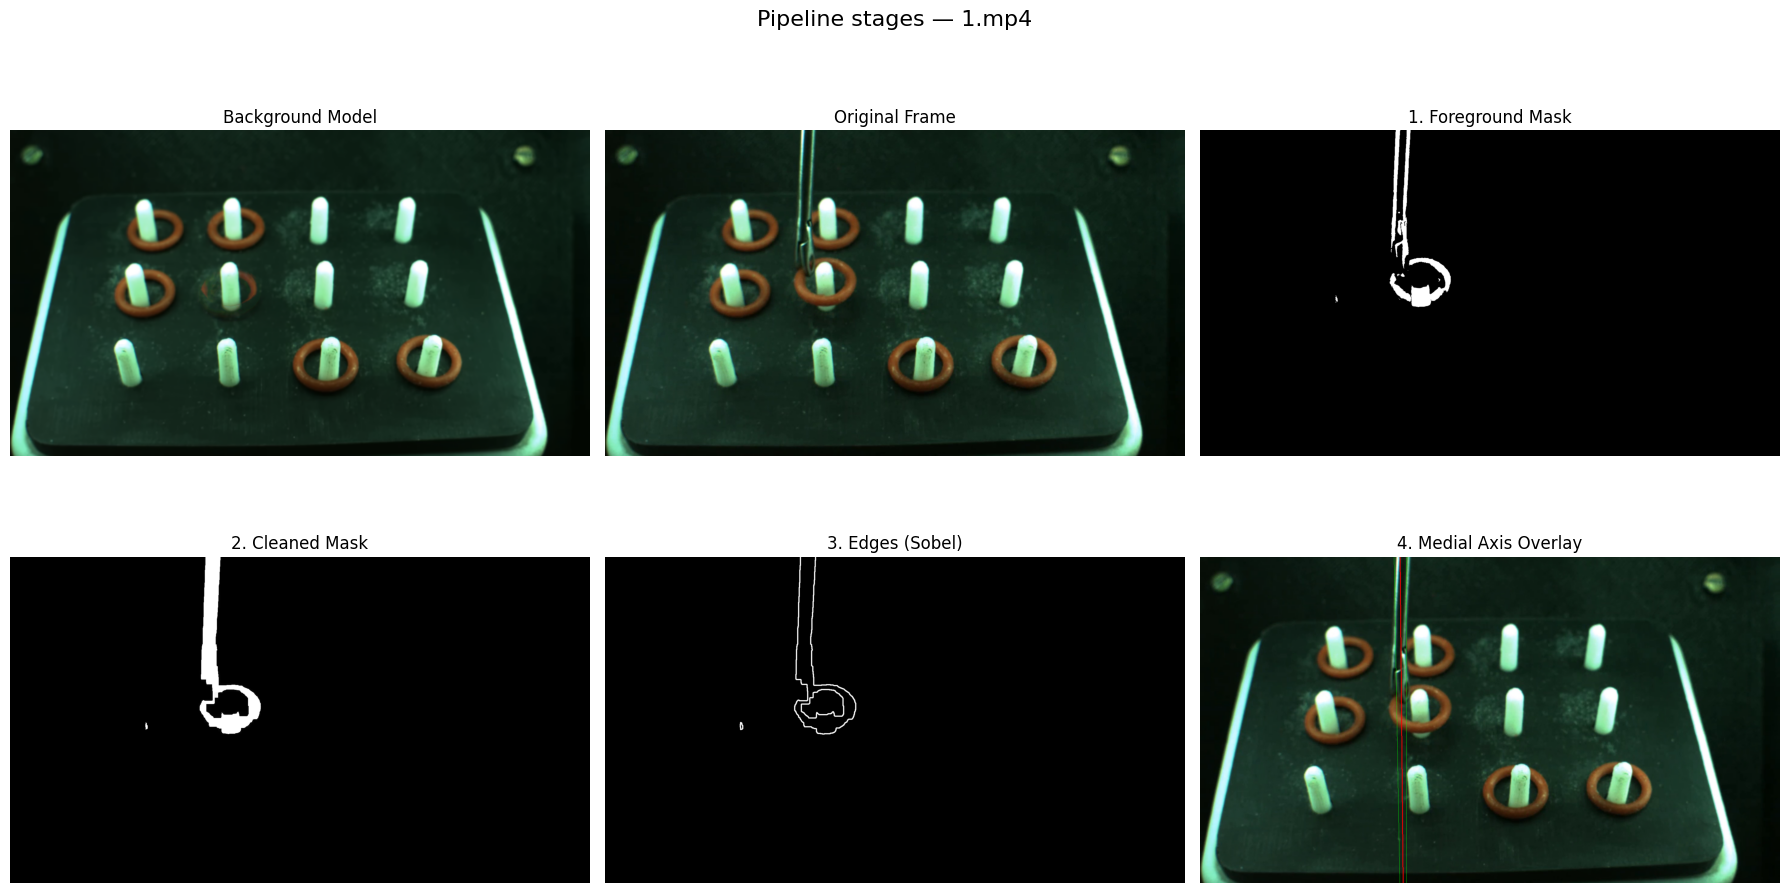

In [19]:
show_stages('1.mp4', bg1, frame1, fg1, cleaned1, edges1, overlay1)

---
## Process Video 2

Runs all 4 stages on `2.mp4`. Each stage skips automatically if its output already exists in `output/`.

In [20]:
bg2, frame2, fg2, cleaned2, edges2, overlay2, modes2 = run_pipeline(os.path.join(VIDEO_DIR, '2.mp4'), 2)

Processing: 2.mp4
  [Stage 1] Building background model (median of all frames)...
    Saved 472 foreground frames → C:\Users\parvc\Documents\College\ARK\Task 2.3\output\foreground_2.mp4
  [Stage 2] Cleaning foreground masks (morphological close)...
    Saved 472 cleaned frames → C:\Users\parvc\Documents\College\ARK\Task 2.3\output\cleaned_2.mp4
  [Stage 3] Detecting edges (Sobel)...
    Saved 472 edge frames → C:\Users\parvc\Documents\College\ARK\Task 2.3\output\edges_2.mp4
  [Stage 4] Computing medial axis overlay...
    Frame     1/472  |  Lines:   6  |  Mode: normal
    Frame    50/472  |  Lines:   6  |  Mode: normal
    Frame   100/472  |  Lines:   6  |  Mode: normal
    Frame   150/472  |  Lines:   6  |  Mode: fallback_all
    Frame   200/472  |  Lines:   6  |  Mode: normal
    Frame   250/472  |  Lines:   6  |  Mode: normal
    Frame   300/472  |  Lines:   6  |  Mode: normal
    Frame   350/472  |  Lines:   6  |  Mode: fallback_all
    Frame   400/472  |  Lines:   6  |  Mode: nor

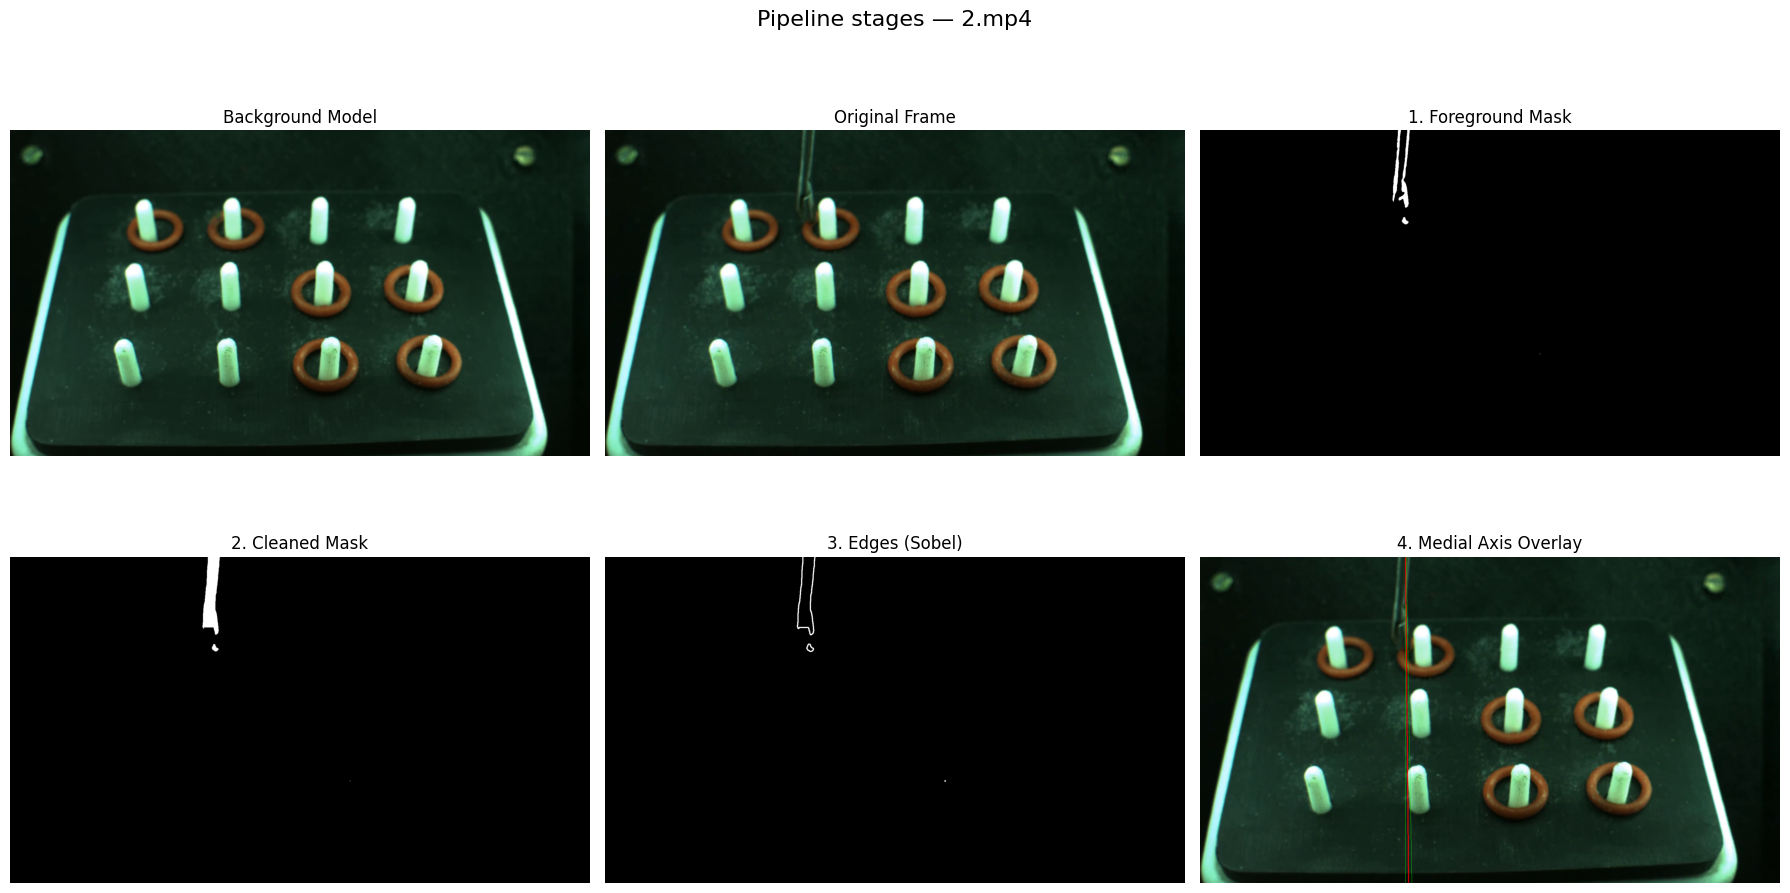

In [21]:
show_stages('2.mp4', bg2, frame2, fg2, cleaned2, edges2, overlay2)

---
## Process Video 3

Runs all 4 stages on `3.mp4`. Each stage skips automatically if its output already exists in `output/`.

In [22]:
bg3, frame3, fg3, cleaned3, edges3, overlay3, modes3 = run_pipeline(os.path.join(VIDEO_DIR, '3.mp4'), 3)

Processing: 3.mp4
  [Stage 1] Building background model (median of all frames)...
    Saved 473 foreground frames → C:\Users\parvc\Documents\College\ARK\Task 2.3\output\foreground_3.mp4
  [Stage 2] Cleaning foreground masks (morphological close)...
    Saved 473 cleaned frames → C:\Users\parvc\Documents\College\ARK\Task 2.3\output\cleaned_3.mp4
  [Stage 3] Detecting edges (Sobel)...
    Saved 473 edge frames → C:\Users\parvc\Documents\College\ARK\Task 2.3\output\edges_3.mp4
  [Stage 4] Computing medial axis overlay...
    Frame     1/473  |  Lines:   6  |  Mode: normal
    Frame    50/473  |  Lines:   6  |  Mode: normal
    Frame   100/473  |  Lines:   6  |  Mode: normal
    Frame   150/473  |  Lines:   6  |  Mode: normal
    Frame   200/473  |  Lines:   6  |  Mode: normal
    Frame   250/473  |  Lines:   6  |  Mode: normal
    Frame   300/473  |  Lines:   6  |  Mode: normal
    Frame   350/473  |  Lines:   6  |  Mode: normal
    Frame   400/473  |  Lines:   6  |  Mode: normal
    Fram

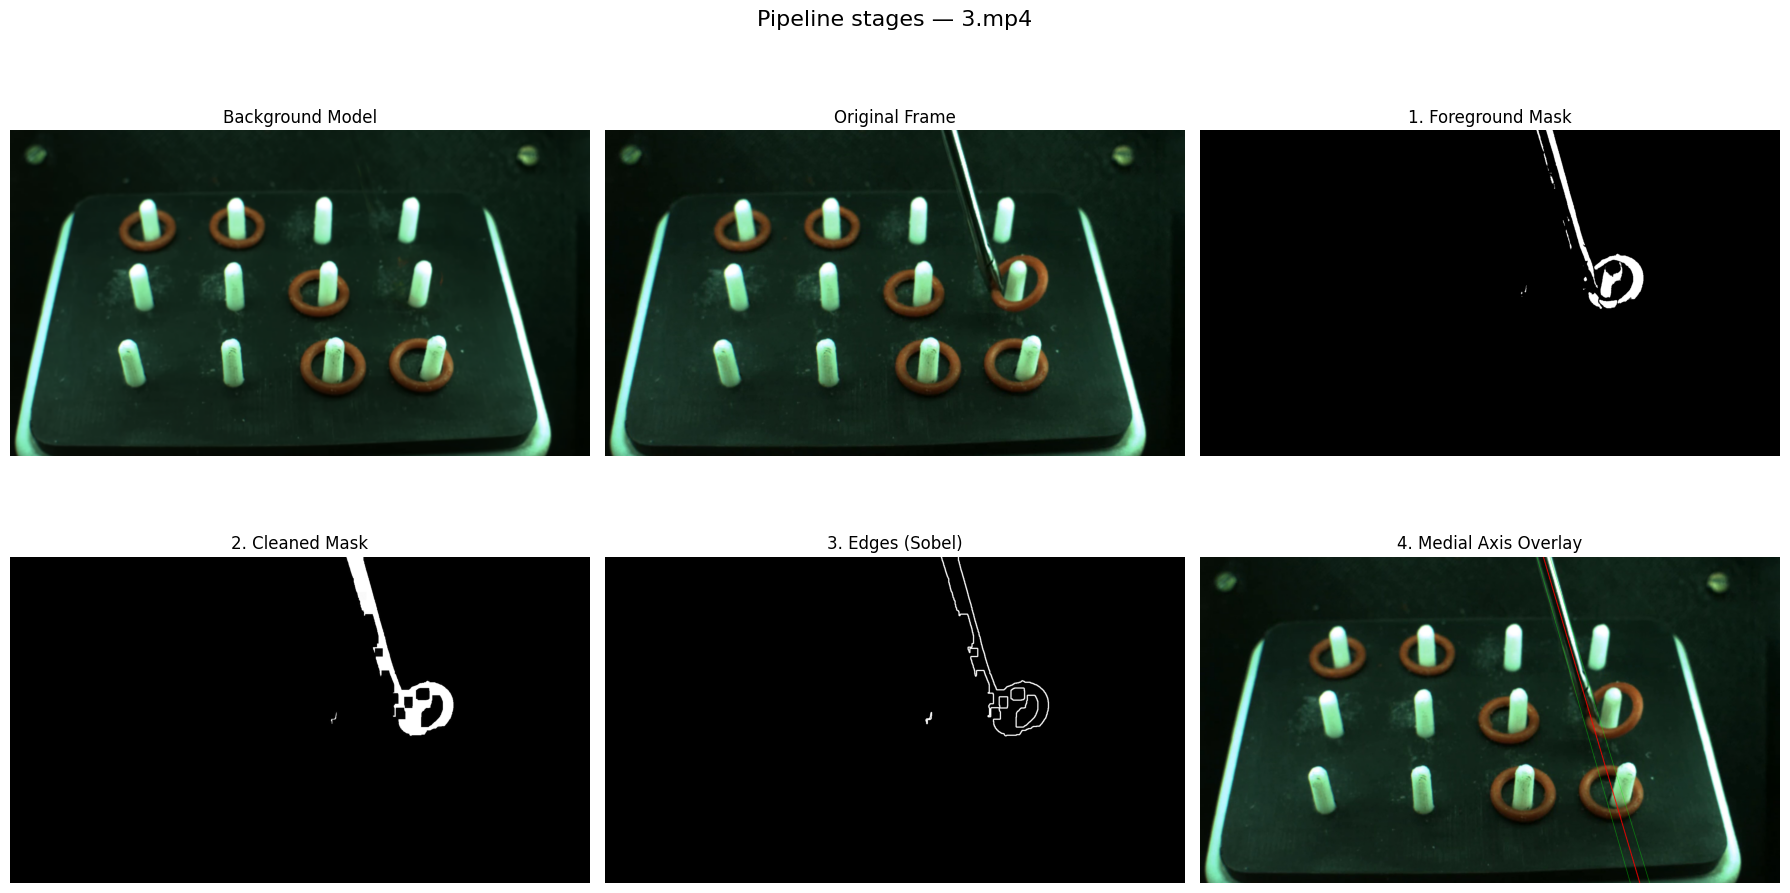

In [23]:
show_stages('3.mp4', bg3, frame3, fg3, cleaned3, edges3, overlay3)

## Debug: Mode Distribution per Video

Bar chart showing how many frames used the **normal** path (intersection-filtered + theta-ranked)
vs the **fallback** path (all lines eliminated → original separation mechanism) vs **prev_result**
(no new pair found, reused last frame's result) vs **no_pair** (nothing detected at all).

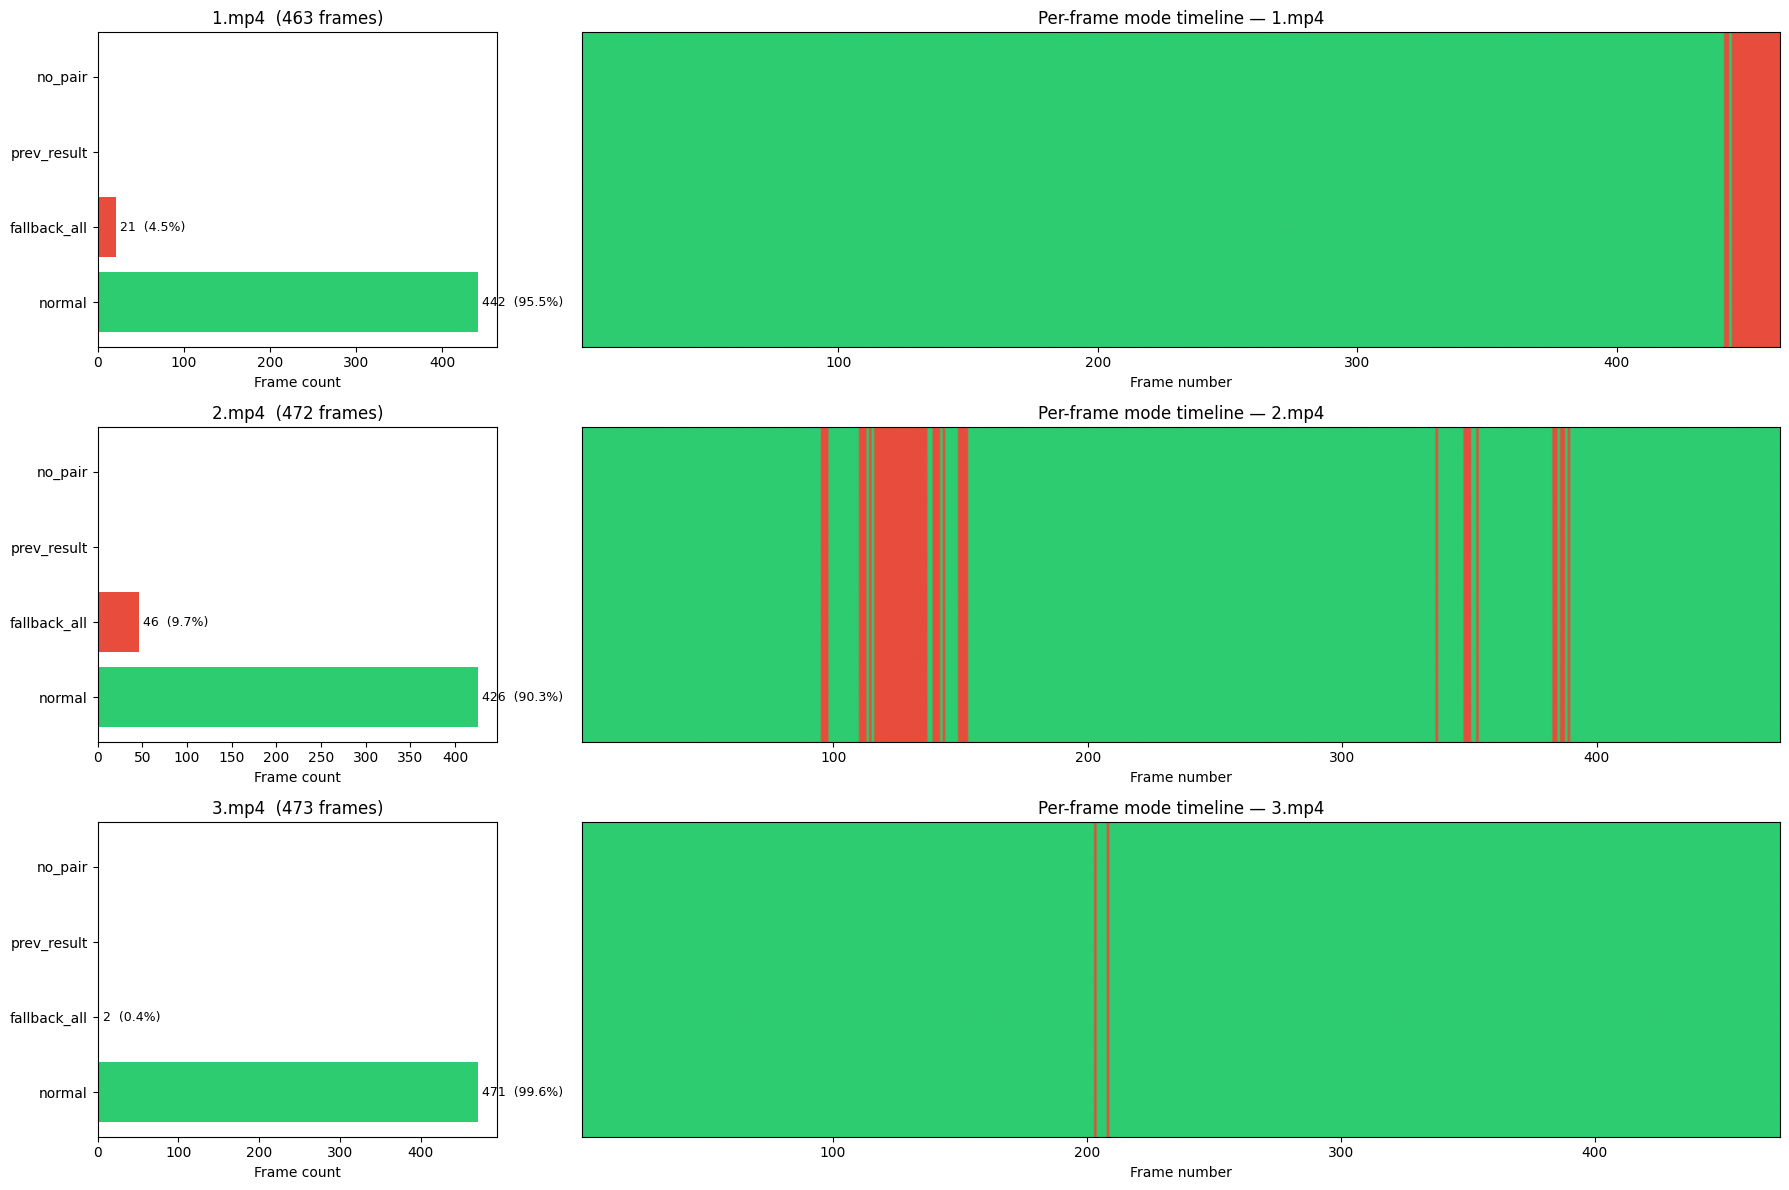

In [24]:
from collections import Counter
from matplotlib.colors import ListedColormap

def plot_mode_debug(all_modes, video_names):
    """Bar chart of classify_edge_pair mode counts for each video,
    plus a per-frame timeline strip."""
    mode_labels = ["normal", "fallback_all", "prev_result", "no_pair"]
    colors_map  = {"normal": "#2ecc71", "fallback_all": "#e74c3c",
                   "prev_result": "#f39c12", "no_pair": "#95a5a6"}

    n_vids = len(all_modes)
    fig, axes = plt.subplots(n_vids, 2, figsize=(18, 4 * n_vids),
                             gridspec_kw={"width_ratios": [1, 3]})
    if n_vids == 1:
        axes = axes[np.newaxis, :]

    for row, (modes, name) in enumerate(zip(all_modes, video_names)):
        counter = Counter(modes)
        total   = len(modes)

        # ── Left: horizontal bar chart ──
        ax_bar = axes[row, 0]
        counts = [counter.get(m, 0) for m in mode_labels]
        bars   = ax_bar.barh(mode_labels, counts,
                             color=[colors_map[m] for m in mode_labels])
        ax_bar.set_xlabel("Frame count")
        ax_bar.set_title(f"{name}  ({total} frames)")
        for bar, cnt in zip(bars, counts):
            if cnt > 0:
                ax_bar.text(bar.get_width() + total * 0.01,
                            bar.get_y() + bar.get_height() / 2,
                            f"{cnt}  ({100*cnt/total:.1f}%)",
                            va='center', fontsize=9)

        # ── Right: per-frame timeline strip ──
        ax_strip = axes[row, 1]
        color_idx = {m: i for i, m in enumerate(mode_labels)}
        strip = np.array([color_idx.get(m, -1) for m in modes])[np.newaxis, :]
        cmap  = ListedColormap([colors_map[m] for m in mode_labels])
        ax_strip.imshow(strip, aspect='auto', cmap=cmap,
                        vmin=0, vmax=len(mode_labels) - 1,
                        extent=[1, total, 0, 1])
        ax_strip.set_yticks([])
        ax_strip.set_xlabel("Frame number")
        ax_strip.set_title(f"Per-frame mode timeline — {name}")

    plt.tight_layout()
    plt.show()


plot_mode_debug(
    [modes1, modes2, modes3],
    ['1.mp4', '2.mp4', '3.mp4']
)

---
## Done

Output videos saved in `Task 2.3/output/` per video (`{idx}` = 1, 2, 3):

| Stage | File | Description |
|-------|------|-------------|
| 1 | `background_{idx}.jpg` | Static background model |
| 1 | `foreground_{idx}.mp4` | Binary foreground masks |
| 2 | `cleaned_{idx}.mp4` | Morphologically cleaned masks |
| 3 | `edges_{idx}.mp4` | Sobel edge maps |
| 4 | `medial_axis_{idx}.mp4` | Final overlay video |
| 4 | `modes_{idx}.npy` | Per-frame mode labels |

**To re-run only a specific stage:** delete its output file(s) and re-run the cell.